/Users/kyungpyokim/Projects/wheel-safe/.venv/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


road_mask: 4150125


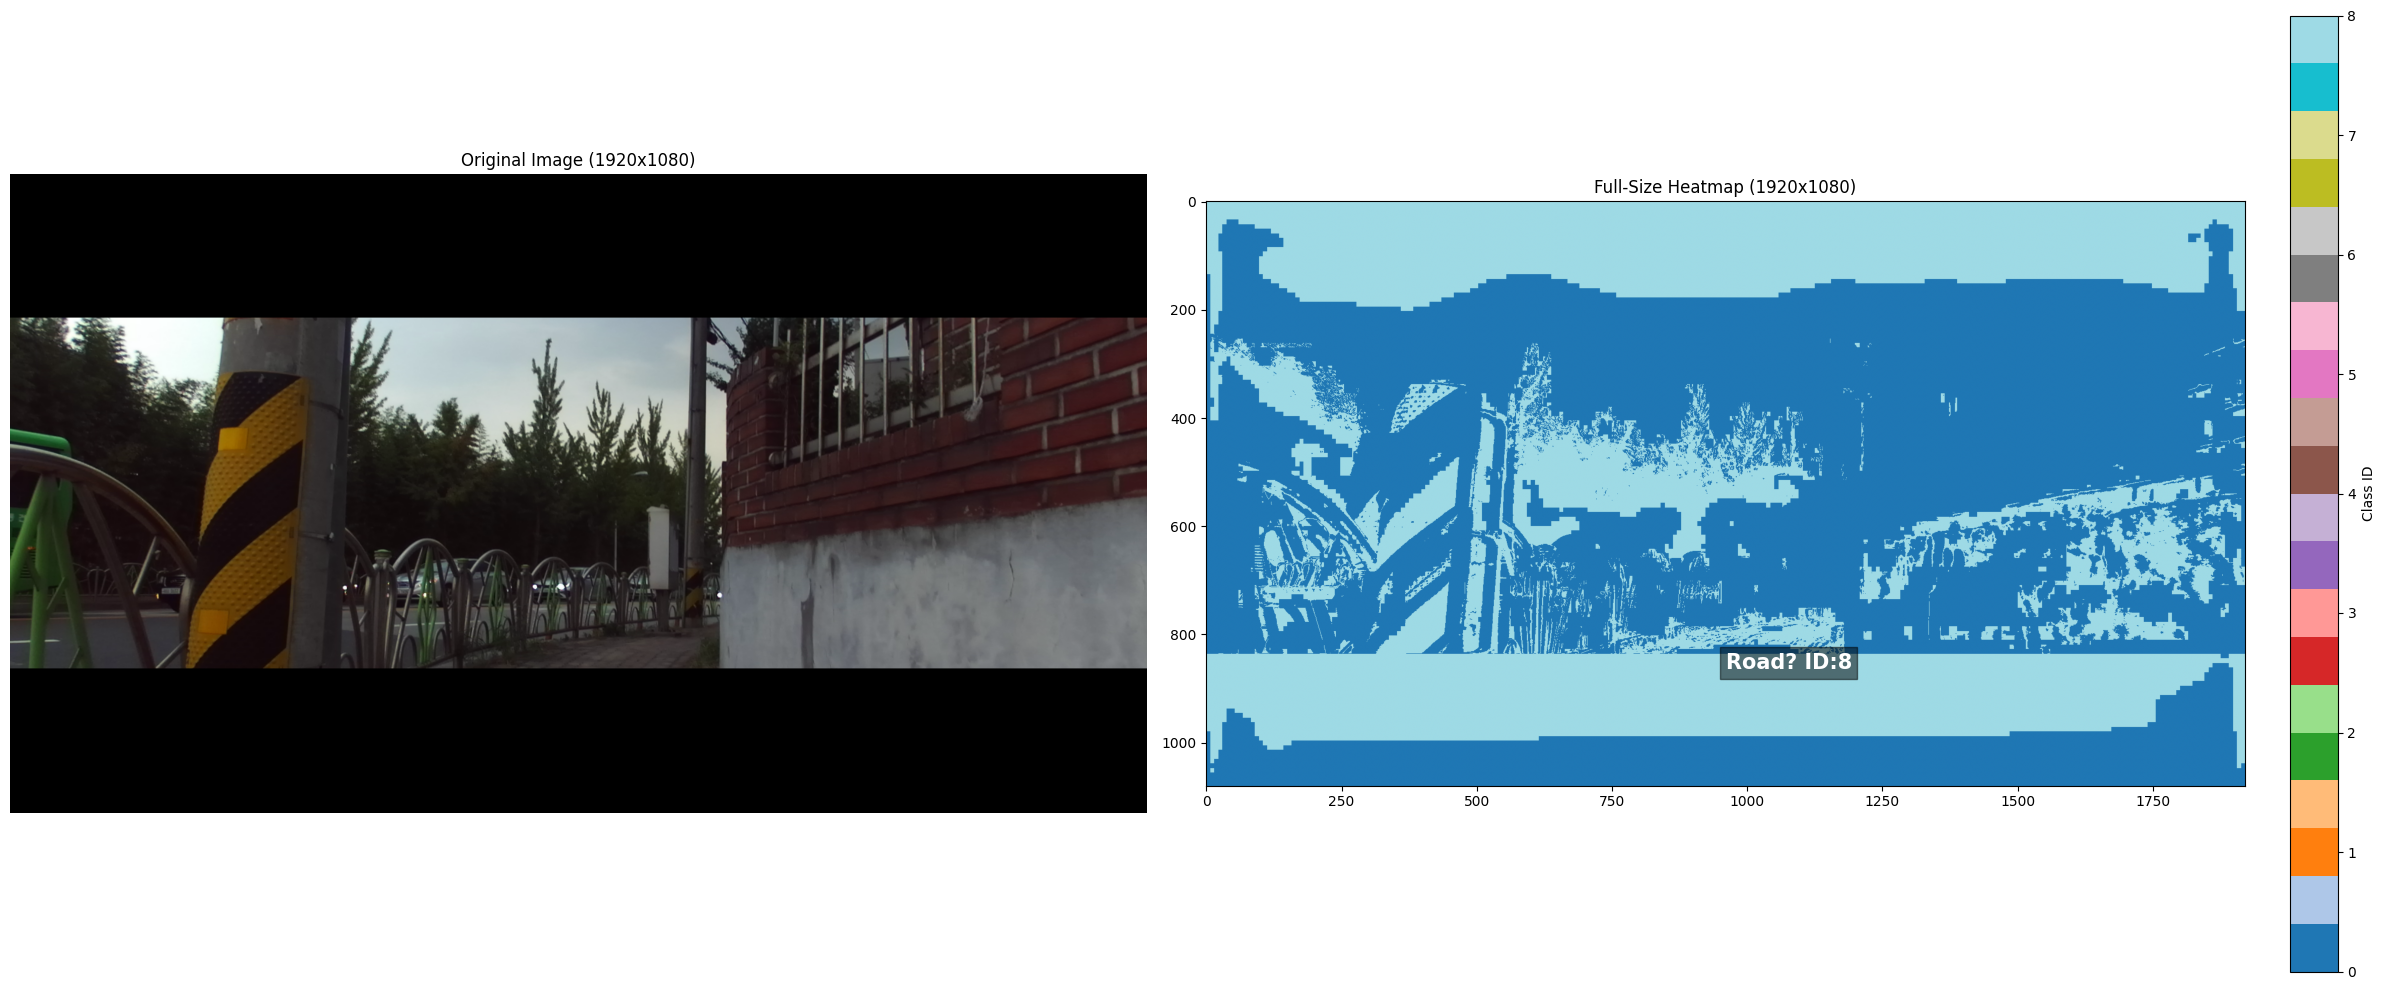

마스크 실제 데이터 값 종류: [  0 255]
[ZED1_KSC_001032] 실제 도로 경사도: 4.26 도
road_mask: 5644680


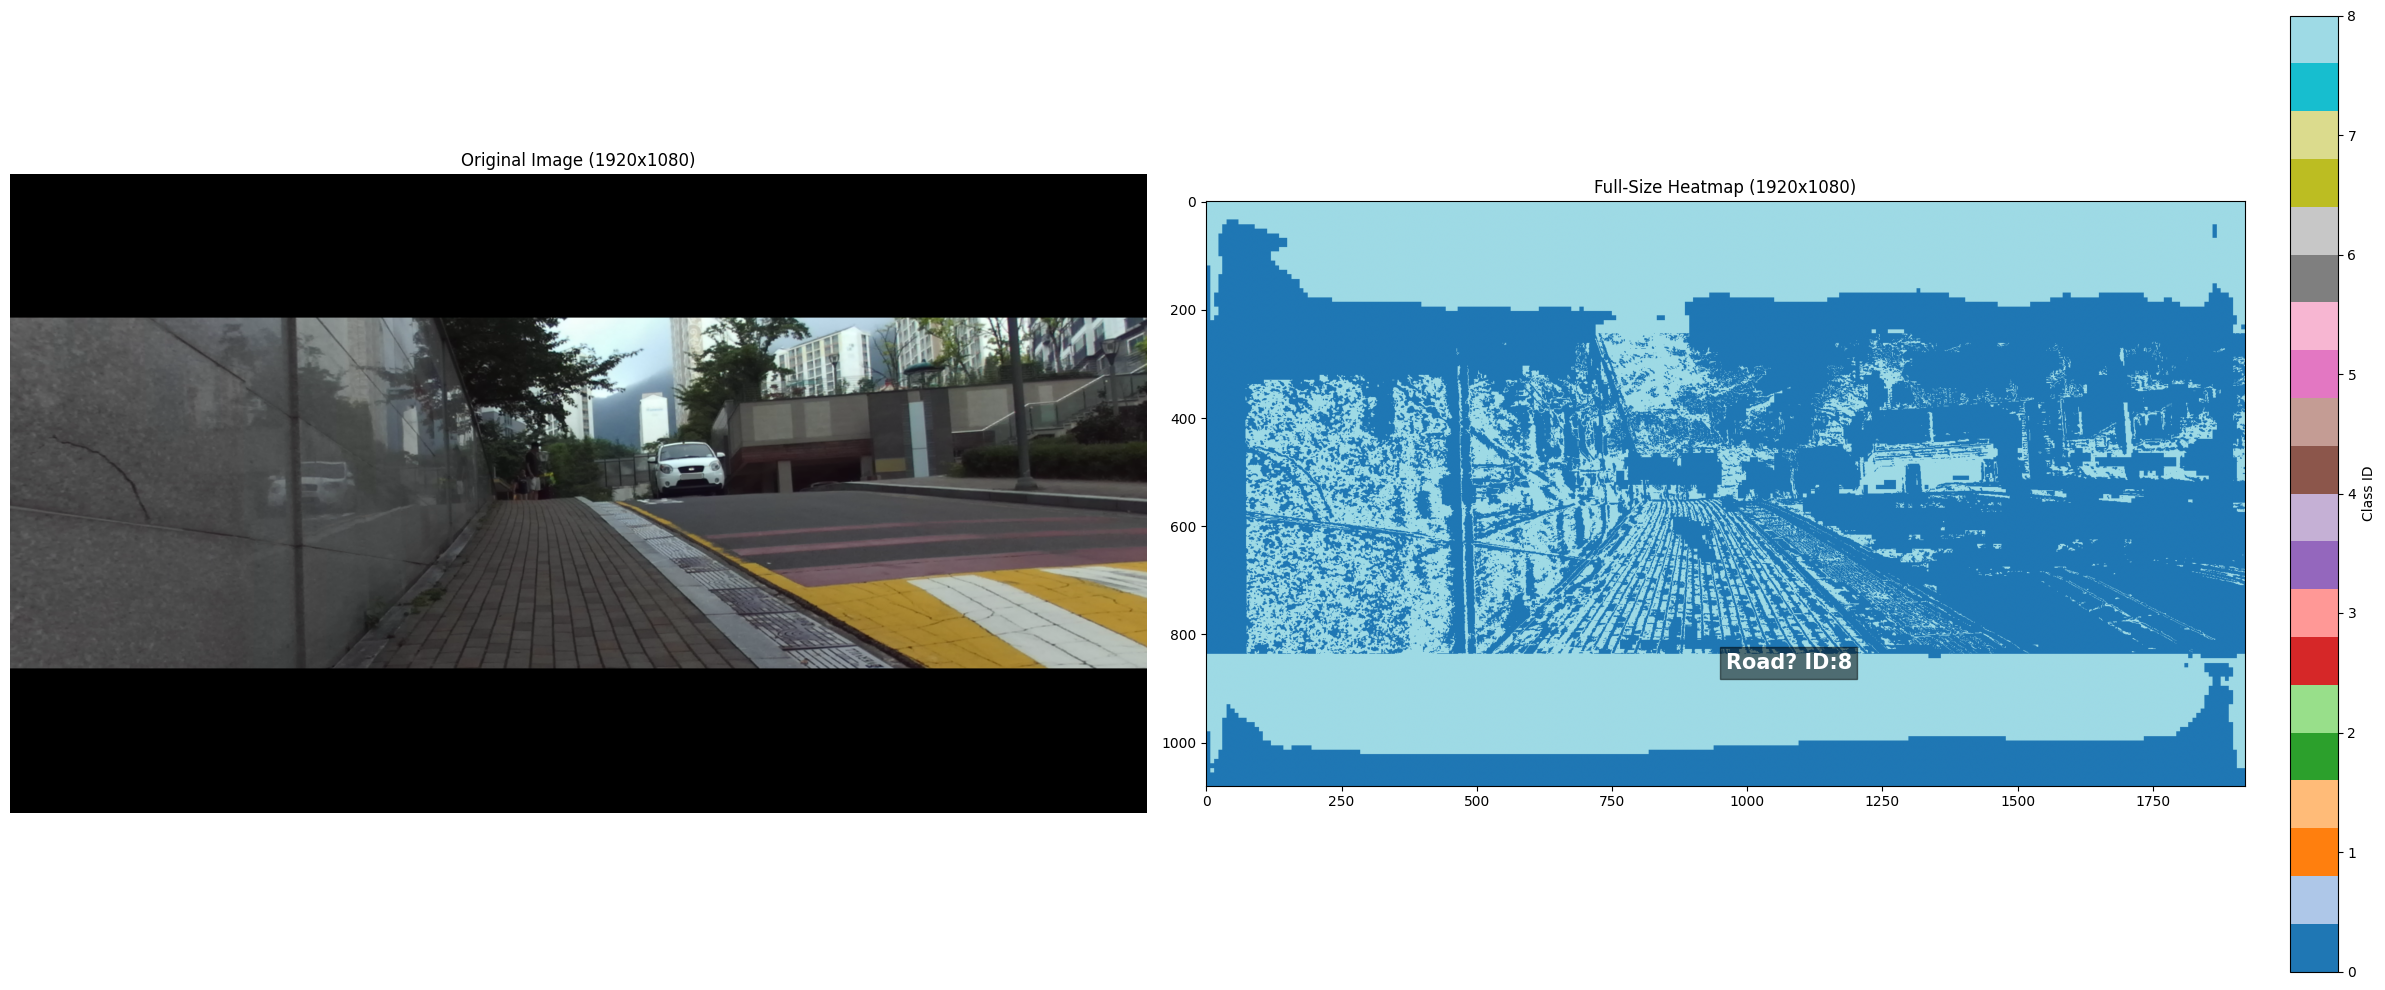

마스크 실제 데이터 값 종류: [  0 255]
[ZED4_KSC_010545] 실제 도로 경사도: 10.49 도


In [7]:
import cv2
import numpy as np

from lib.utils.path import raw_data_path
from v2.estimate_road_slope import get_calibrated_slope
from v2.pidnet_onnx_predictor import create_model

model = create_model()

image_names = ['ZED1_KSC_001032', 'ZED4_KSC_010545']
foder_nums = ['001', '007']

for _, (name, num) in enumerate(list(zip(image_names, foder_nums, strict=False))):
    folder_path = raw_data_path(num)
    conf_file = folder_path / f'Depth_{num}.conf'
    left_img = folder_path / f'{name}_left.png'
    conf_img = folder_path / f'{name}_confidence.png'
    disp_img = folder_path / f'{name}_disp16.png'

    # 2. 데이터 로드
    disp_map = cv2.imread(str(disp_img), cv2.IMREAD_UNCHANGED).astype(np.float32)
    conf_map = (
        cv2.imread(str(conf_img), cv2.IMREAD_UNCHANGED).astype(np.float32) / 255.0
    )

    road_mask = model.get_road_mask(left_img, conf_map)

    # 3. [핵심] 레터박스 제거 (Refinement)
    # 검은 빈 공간은 스테레오 매칭이 불가능하므로 conf_map 값이 0에 가깝습니다.
    # road_mask이면서 동시에 신뢰도가 0.5 이상인 곳만 진짜 도로로 인정합니다.
    refined_mask = (road_mask == 255) & (conf_map > 0.5)
    refined_mask = (refined_mask.astype(np.uint8)) * 255

    # 4. 정제된 마스크로 경사도 계산
    final_slope = get_calibrated_slope(disp_map, conf_map, refined_mask, conf_file)

    if final_slope is not None:
        print(f'[{name}] 실제 도로 경사도: {final_slope:.2f} 도')

# for _, (name, num) in enumerate(list(zip(image_names, foder_nums, strict=False))):
#     folder_path = raw_data_path(num)
#     conf_file = folder_path / f'Depth_{num}.conf'
#     left_img = folder_path / f'{name}_left.png'
#     conf_img = folder_path / f'{name}_confidence.png'
#     disp_img = folder_path / f'{name}_disp16.png'

#     road_mask = model.get_road_mask(left_img)

#     disp_map = cv2.imread(str(disp_img), cv2.IMREAD_UNCHANGED).astype(np.float32)
#     conf_map = (
#         cv2.imread(str(conf_img), cv2.IMREAD_UNCHANGED).astype(np.float32) / 255.0
#     )

#     final_slope = get_calibrated_slope(disp_map, conf_map, road_mask, conf_file)

#     if final_slope is not None:
#         print(f'[{name}] 실제 도로 경사도: {final_slope:.2f} 도')
